In [1]:
import os
import sys

notebook_dir = os.path.abspath("")
print(f"Notebook directory: {notebook_dir}")

project_dir = os.path.dirname(notebook_dir)
print(f"Project directory: {project_dir}")

if project_dir not in sys.path:
    print("Project directory is not in system path!!\nAppending....")
    sys.path.append(project_dir)
    print("Done")

Notebook directory: /mnt/work/TIME_SERIES_LAB/notebooks
Project directory: /mnt/work/TIME_SERIES_LAB
Project directory is not in system path!!
Appending....
Done


In [2]:
import pandas as pd
import numpy as np

from src.config import get_config_from_yaml

In [3]:
config_path = project_dir+"/configs/config.yaml"
cfg = get_config_from_yaml(config_path)
cfg

Config(name='bera', data=DataConfig(path='data/beer_dataset.csv', split_size=168, index_col=None), visualizer=VisualizationConfig(plot_path='plots/', decomposition_model='additive', style_theme='seaborn-v0_8-whitegrid', dpi=150, default_figsize=(14, 7), acf_lags=40), models=ModelsConfig(decompose=DecomposeConfig(model='multiplicative', period=12), exponential_smoothing=ExponentialConfig(trend='add', seasonal='mul', seasonal_periods=12), sarima=SARIMAConfig(p=1, d=1, q=1, P=1, D=1, Q=1)))

In [4]:
cfg.visualizer.default_figsize

(14, 7)

In [5]:
from src.data import DataClass

In [6]:
cfg.data.path = project_dir + "/" + cfg.data.path
cfg.data.index_col = "Date"
dataset = DataClass(cfg.data)

In [7]:
dataset.train

,Observation,Year,Quarter,Period,Beer Production (ML)
Date,,,,,
1956-01-01,1,1956,Q1,1956 Q1,284
1956-04-01,2,1956,Q2,1956 Q2,213
1956-07-01,3,1956,Q3,1956 Q3,227
1956-10-01,4,1956,Q4,1956 Q4,308
1957-01-01,5,1957,Q1,1957 Q1,262
...,...,...,...,...,...
1996-10-01,164,1996,Q4,1996 Q4,507
1997-01-01,165,1997,Q1,1997 Q1,432
1997-04-01,166,1997,Q2,1997 Q2,398


In [8]:
from src.visualizer import Visualizer

In [9]:
help(Visualizer)

Help on class Visualizer in module src.visualizer:

class Visualizer(builtins.object)
 |  Visualizer(dataset: 'DataClass', config: 'VisualizationConfig') -> 'None'
 |
 |  Orchestrates visualization generations for time series evaluation, utilizing local caching.
 |
 |  Methods defined here:
 |
 |  __init__(self, dataset: 'DataClass', config: 'VisualizationConfig') -> 'None'
 |      Initializes the visualizer instance.
 |
 |      Args:
 |          dataset (DataClass): Connected dataset ingestor utility.
 |          config (VisualizationConfig): Visual configuration parameters.
 |
 |  plot_autocorrelation(self, target_col: 'str') -> 'None'
 |      Renders Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots side-by-side.
 |
 |  plot_envelope_components(self, target_col: 'str', distance: 'Optional[int]' = None, prominence: 'Optional[float]' = None) -> 'None'
 |      Analyzes time series composition behavior (additive vs multiplicative) via envelope geometry.
 |
 |  plot_line_ser

In [10]:
cfg.visualizer.decomposition_model = 'multiplicative'

In [11]:
vis = Visualizer(dataset, cfg.visualizer)

In [ ]:
vis.plot_autocorrelation("Beer Production (ML)")

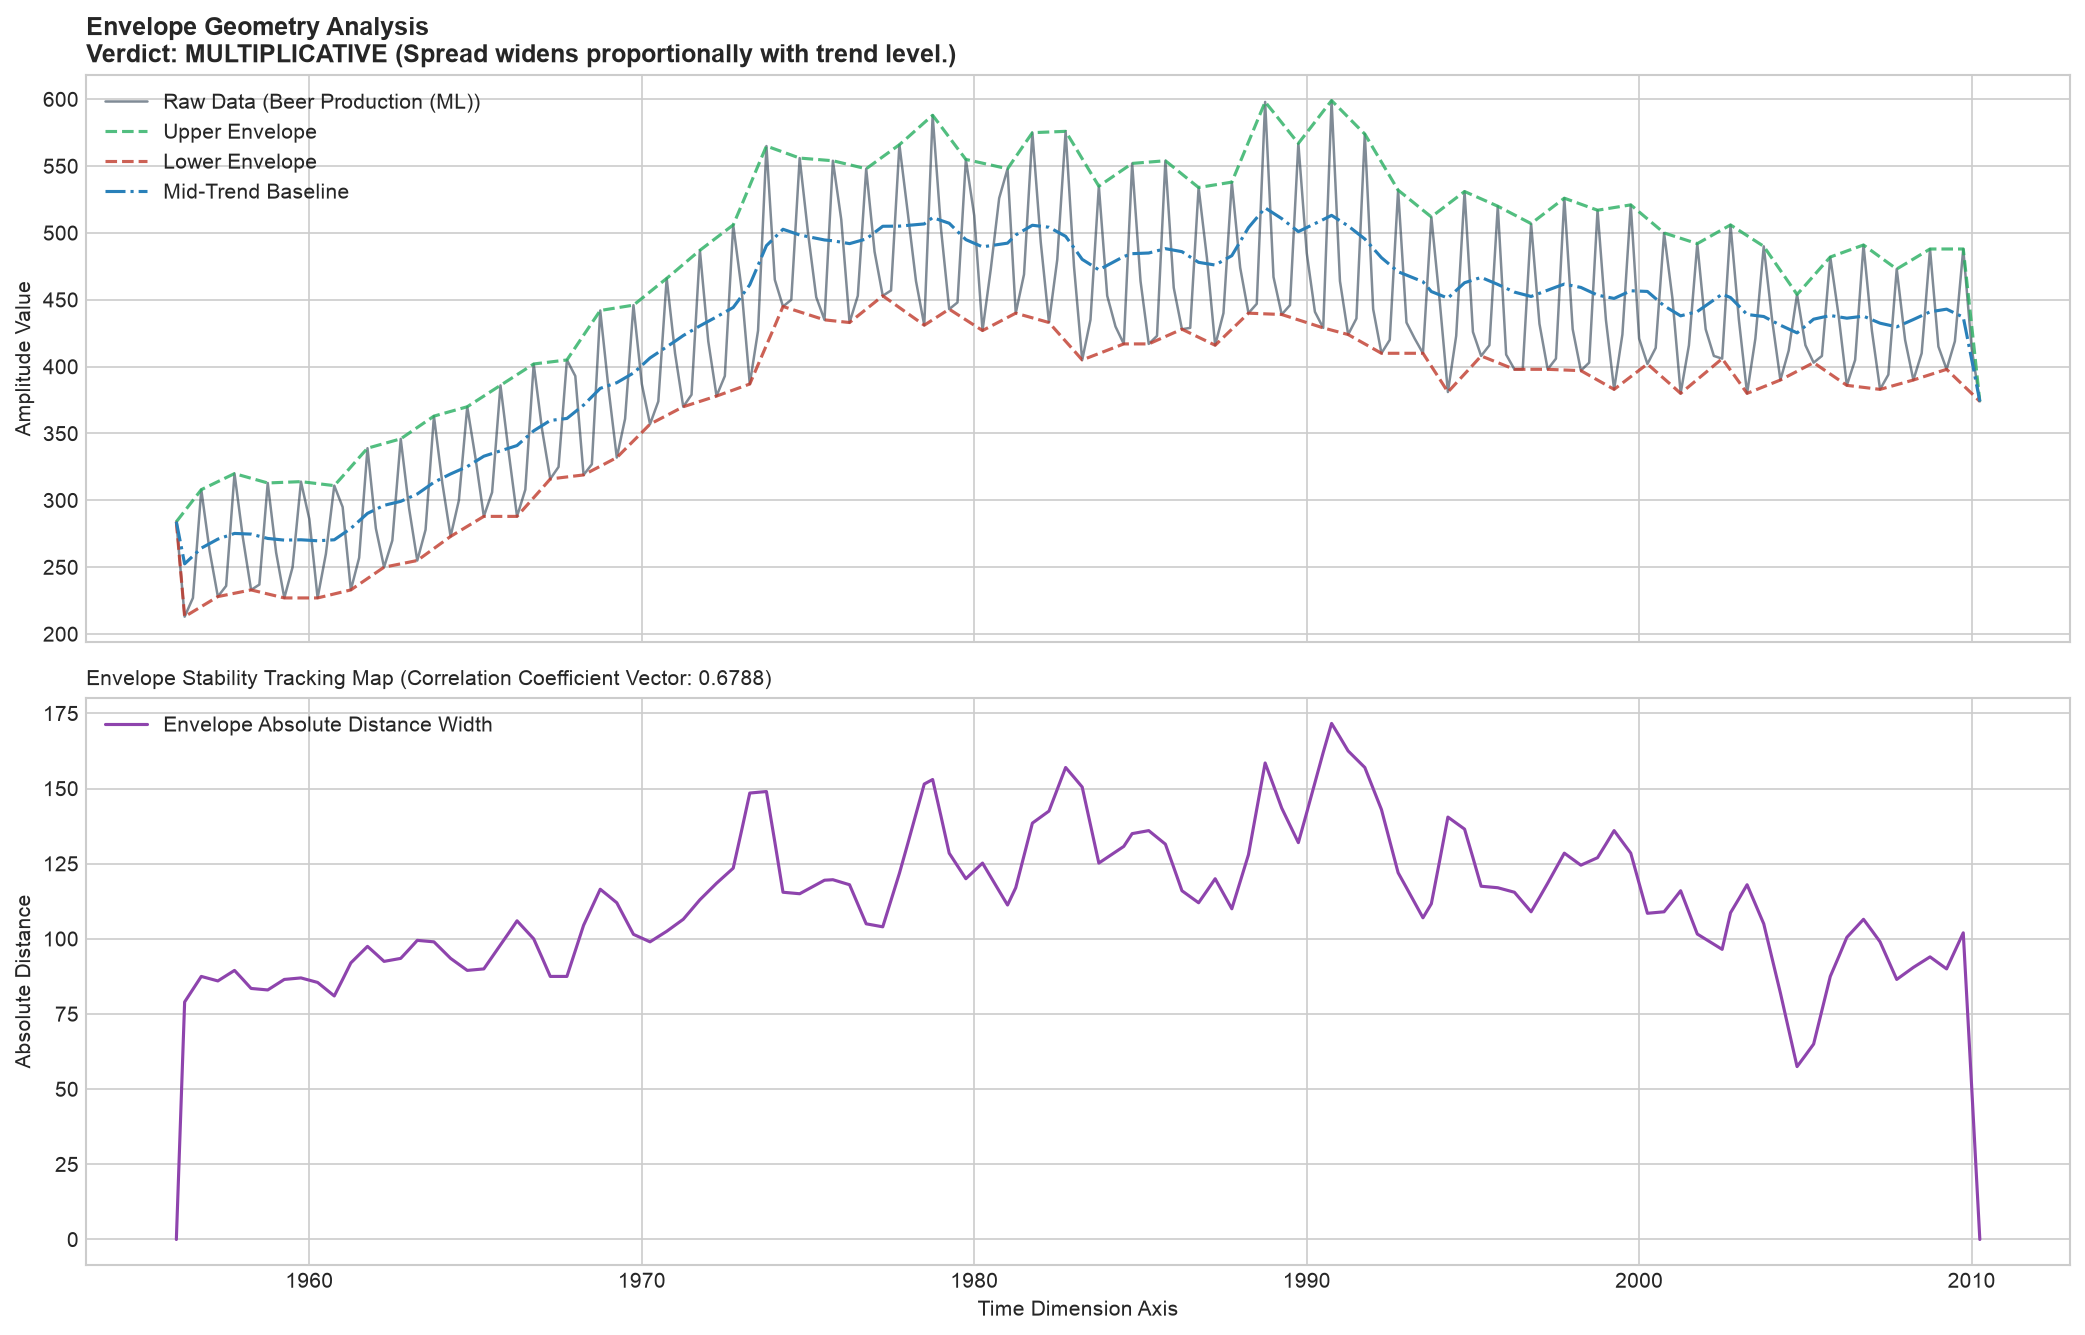

In [44]:
vis.plot_envelope_components("Beer Production (ML)")

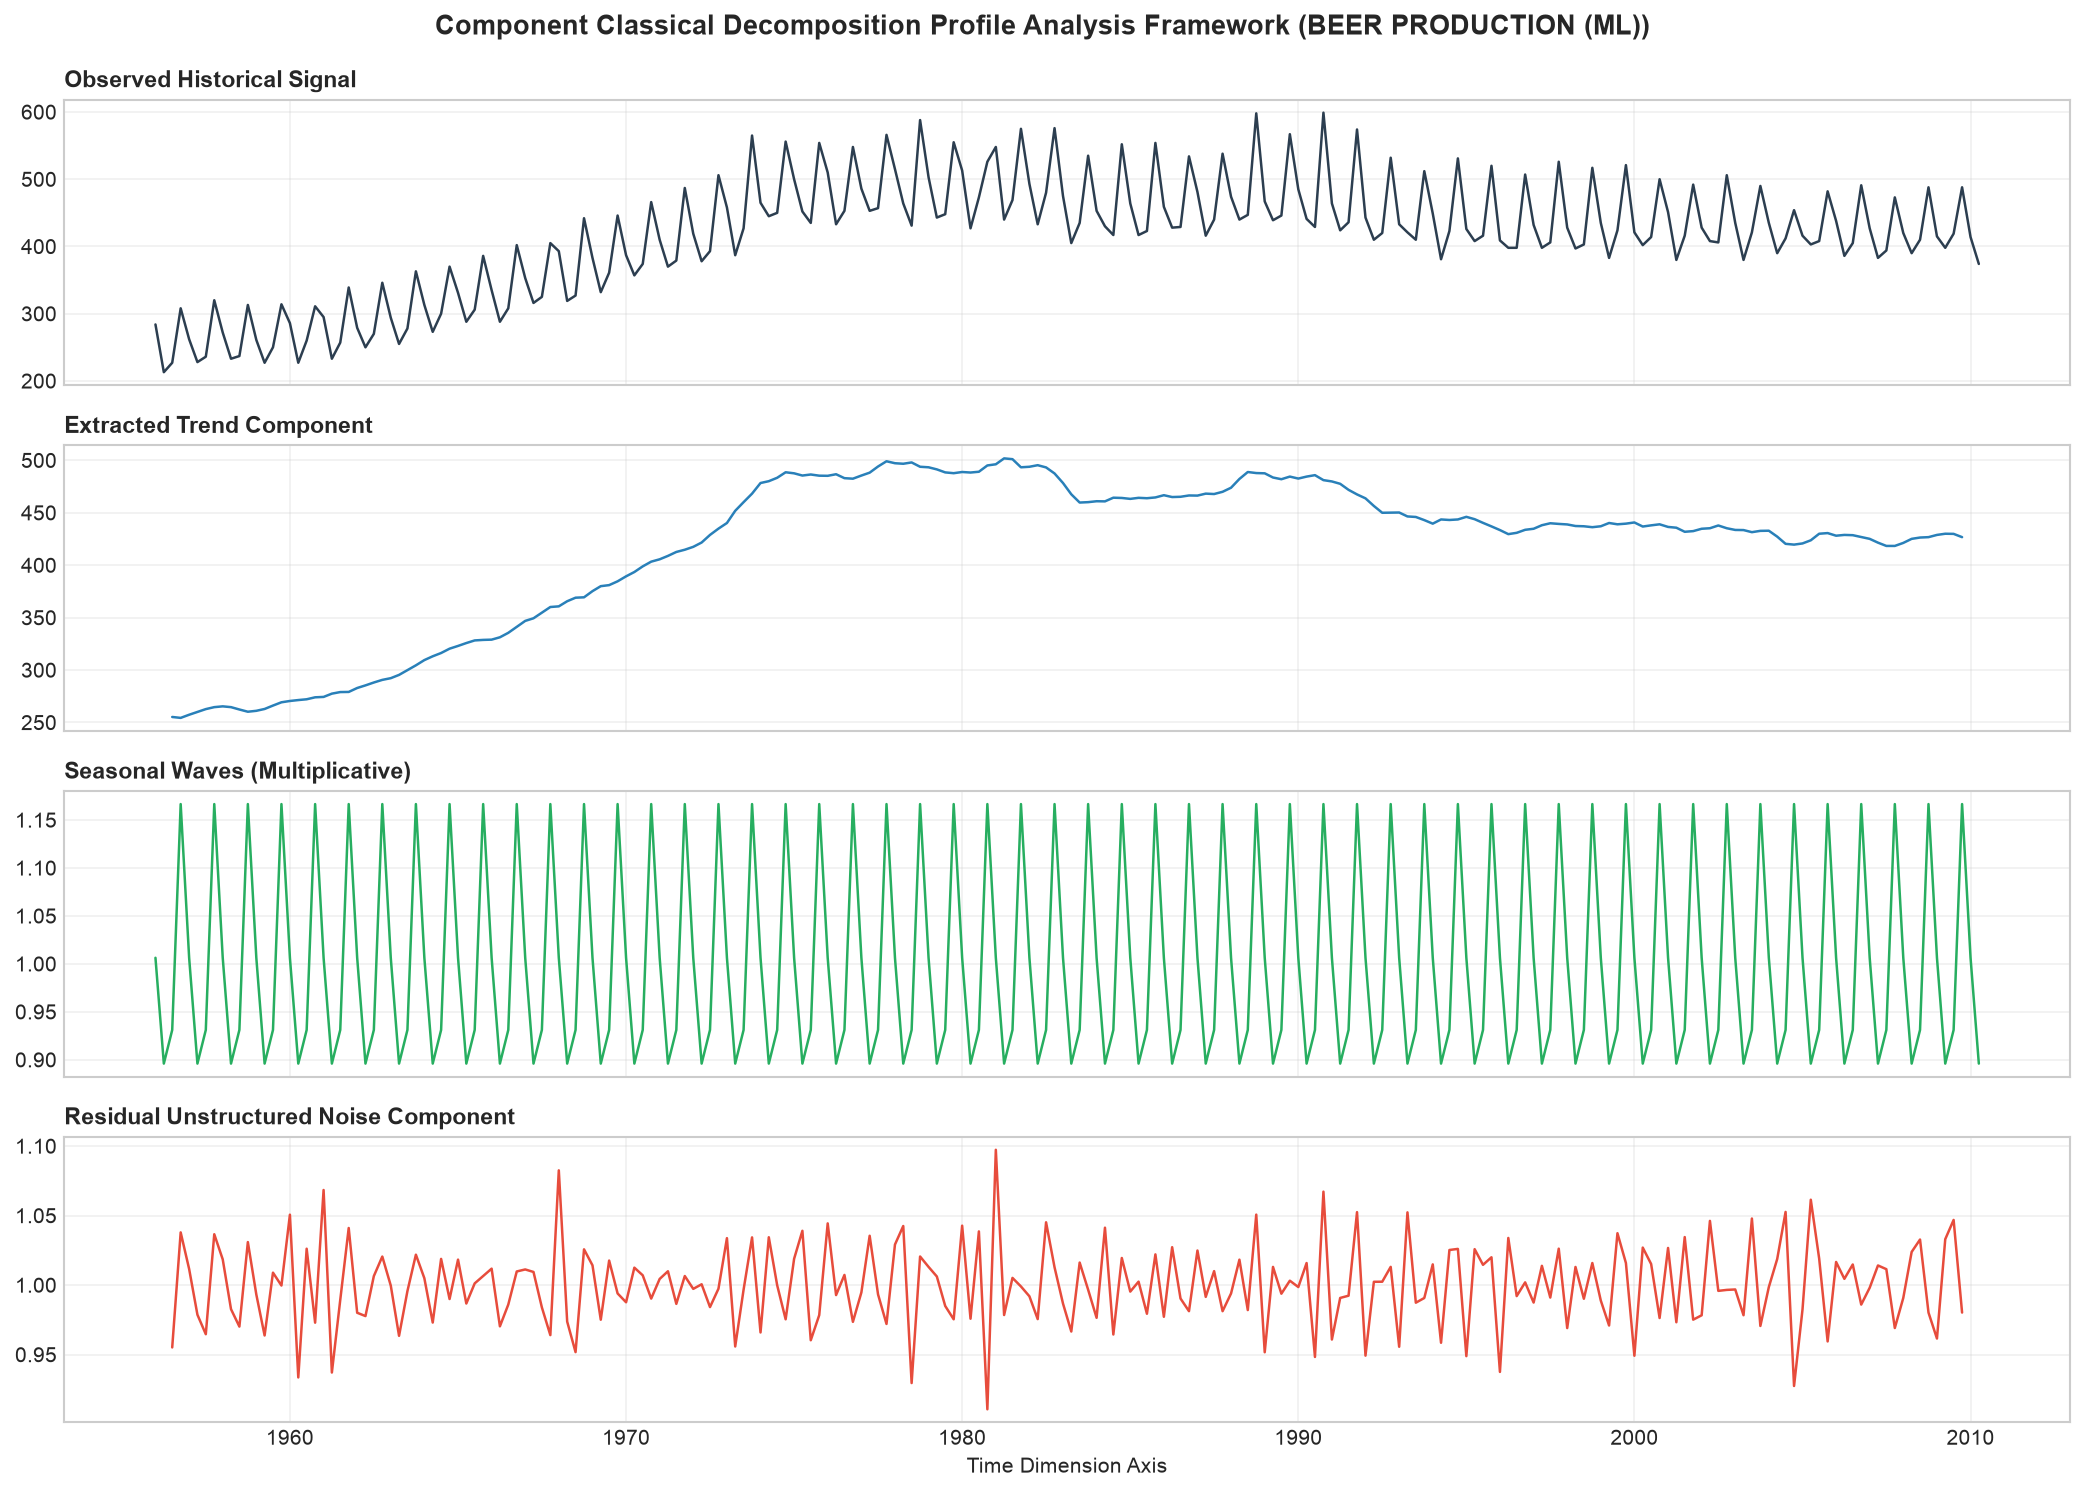

In [50]:
vis.plot_seasonal_decomposition("Beer Production (ML)")

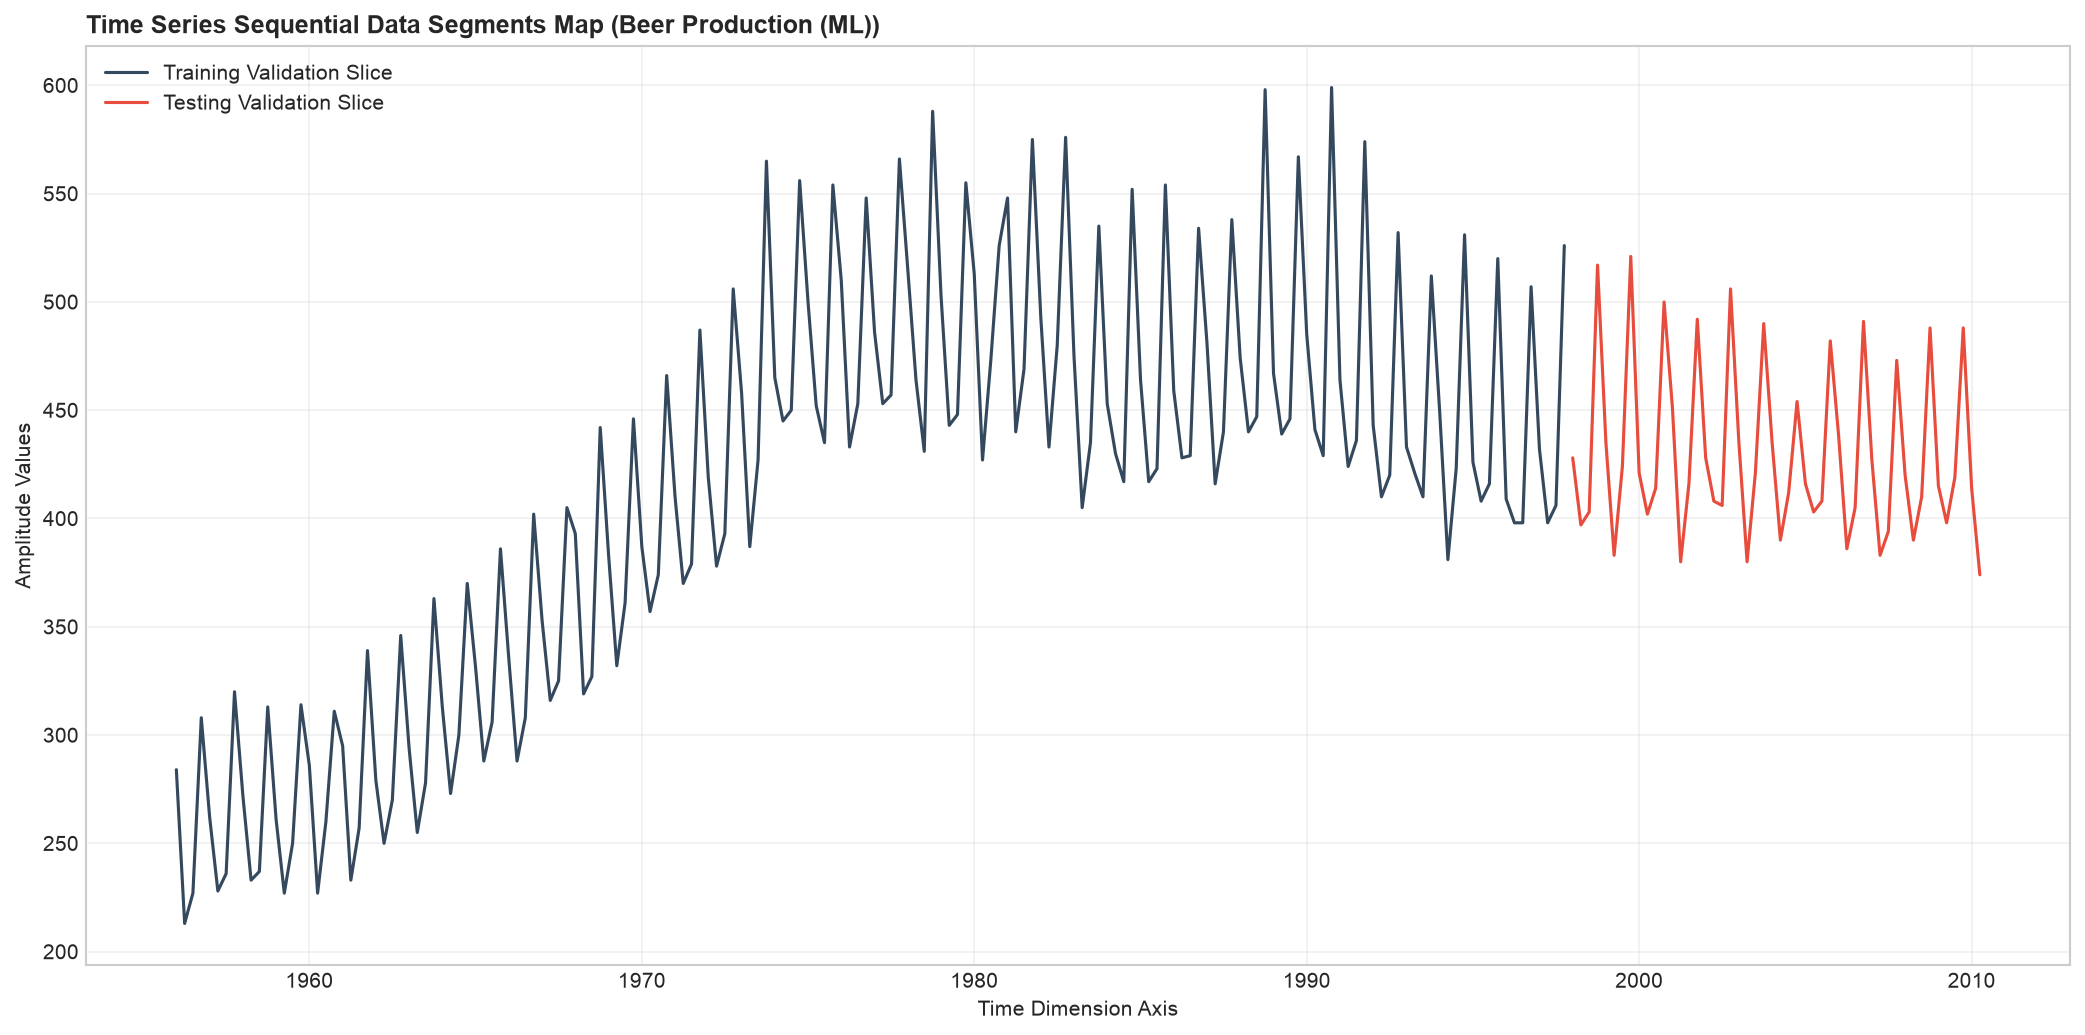

In [52]:
vis.plot_line_series("Beer Production (ML)")